CSV_PATH: C:\Users\Steven\Desktop\Final_project_202218020208_lighweight_pneumothorax_detection\ConvUnet\AutoDL\Baseline_ECA_LSMF_samplerUNetPP_GEMopt_AutoDL_Output\learning_curve_results.csv
OUT_DIR: C:\Users\Steven\Desktop\Final_project_202218020208_lighweight_pneumothorax_detection\ConvUnet\AutoDL\Baseline_ECA_LSMF_samplerUNetPP_GEMopt_AutoDL_Output\outputs_learning_curve
   fraction  n_train  pos_train  neg_train  best_epoch  train_acc  train_f1  \
0       0.1      854        190        664          21   0.989461  0.976864   
1       0.2     1708        381       1327          22   0.911593  0.832780   
2       0.4     3416        761       2655          22   0.944379  0.885680   
3       0.6     5124       1142       3982          14   0.965457  0.927607   
4       0.8     6832       1522       5310          13   0.976874  0.950283   
5       1.0     8540       1903       6637           7   0.946721  0.887682   

   train_roc_auc  train_pr_auc   val_acc    val_f1  val_roc_auc  val_

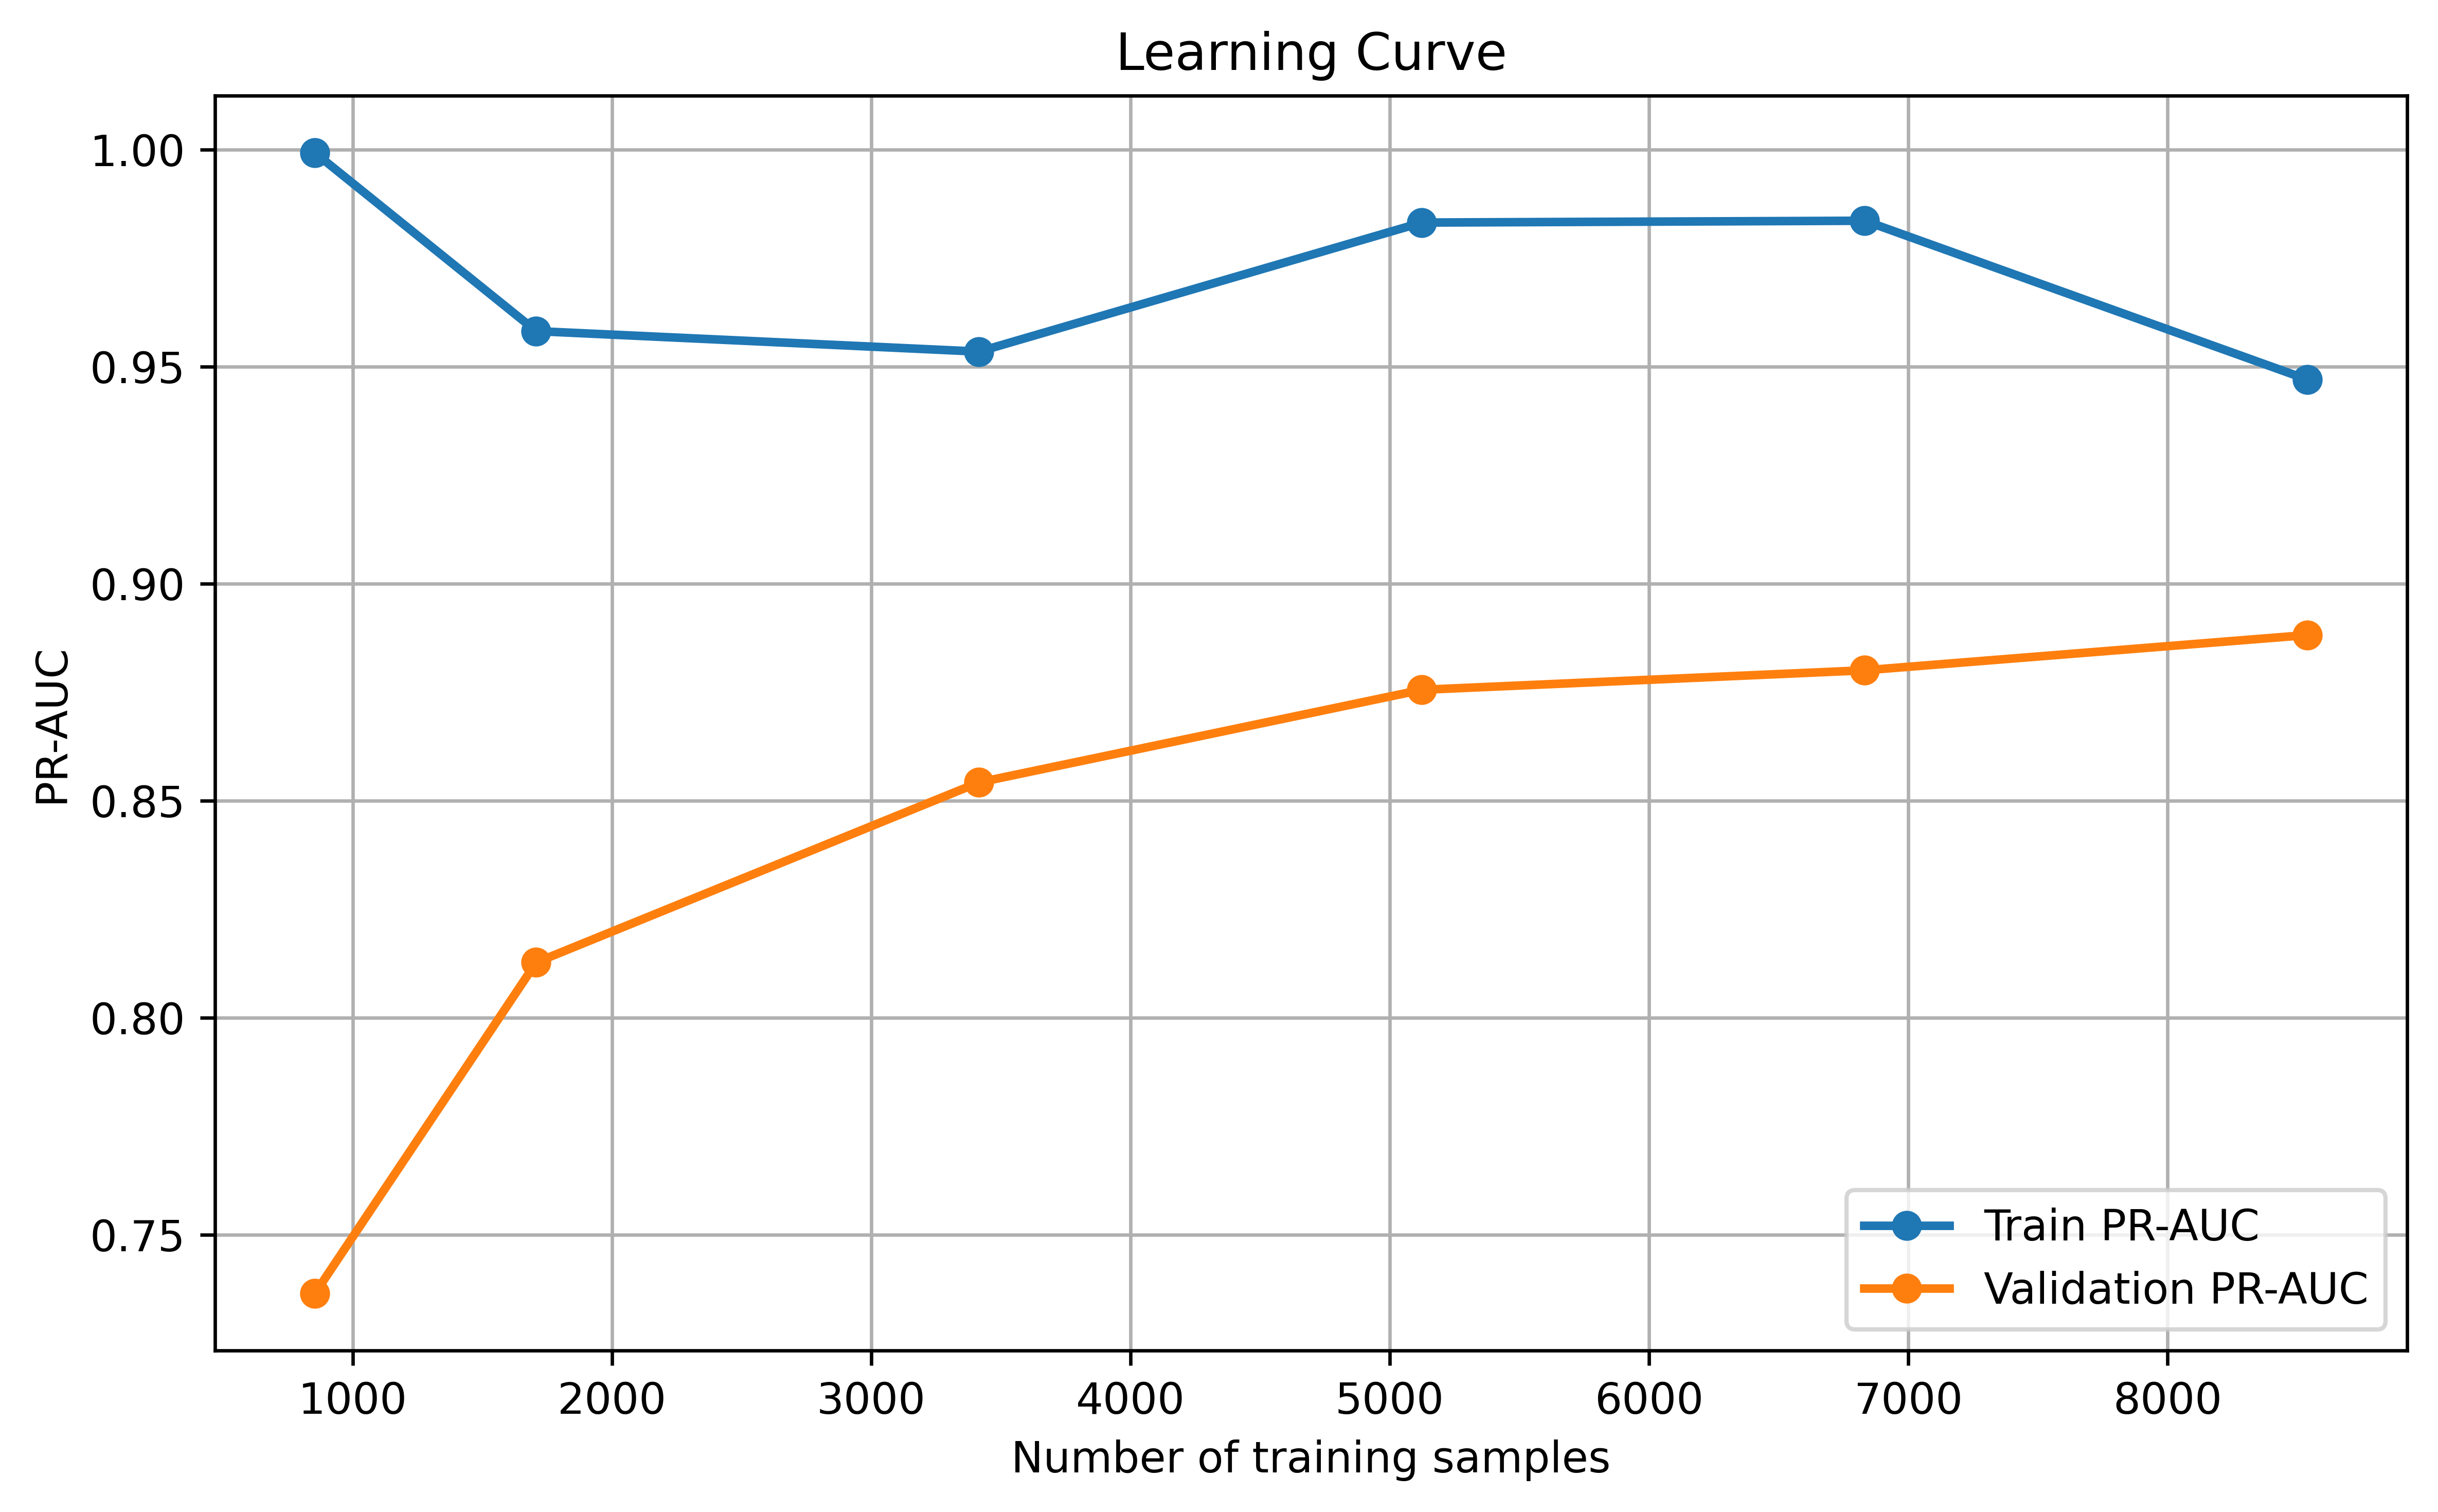

Saved figure to: C:\Users\Steven\Desktop\Final_project_202218020208_lighweight_pneumothorax_detection\ConvUnet\AutoDL\Baseline_ECA_LSMF_samplerUNetPP_GEMopt_AutoDL_Output\outputs_learning_curve\standard_learning_curve_pr_auc.png


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. Paths =====
PROJECT_ROOT = r"C:\Users\Steven\Desktop\Final_project_202218020208_lighweight_pneumothorax_detection\ConvUnet\AutoDL\Baseline_ECA_LSMF_samplerUNetPP_GEMopt_AutoDL_Output"
CSV_PATH = os.path.join(PROJECT_ROOT, "learning_curve_results.csv")
OUT_DIR = os.path.join(PROJECT_ROOT, "outputs_learning_curve")
os.makedirs(OUT_DIR, exist_ok=True)

print("CSV_PATH:", CSV_PATH)
print("OUT_DIR:", OUT_DIR)

# ===== 2. Read CSV =====
results_df = pd.read_csv(CSV_PATH)
results_df = results_df.sort_values("n_train").reset_index(drop=True)

print(results_df)

# ===== 3. Plot standard learning curve =====
plt.figure(figsize=(8, 5), dpi = 600)

plt.plot(
    results_df["n_train"],
    results_df["train_pr_auc"],
    marker="o",
    linewidth=2,
    label="Train PR-AUC"
)

plt.plot(
    results_df["n_train"],
    results_df["val_pr_auc"],
    marker="o",
    linewidth=2,
    label="Validation PR-AUC"
)

plt.xlabel("Number of training samples")
plt.ylabel("PR-AUC")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()

fig_path = os.path.join(OUT_DIR, "standard_learning_curve_pr_auc.png")
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved figure to:", fig_path)

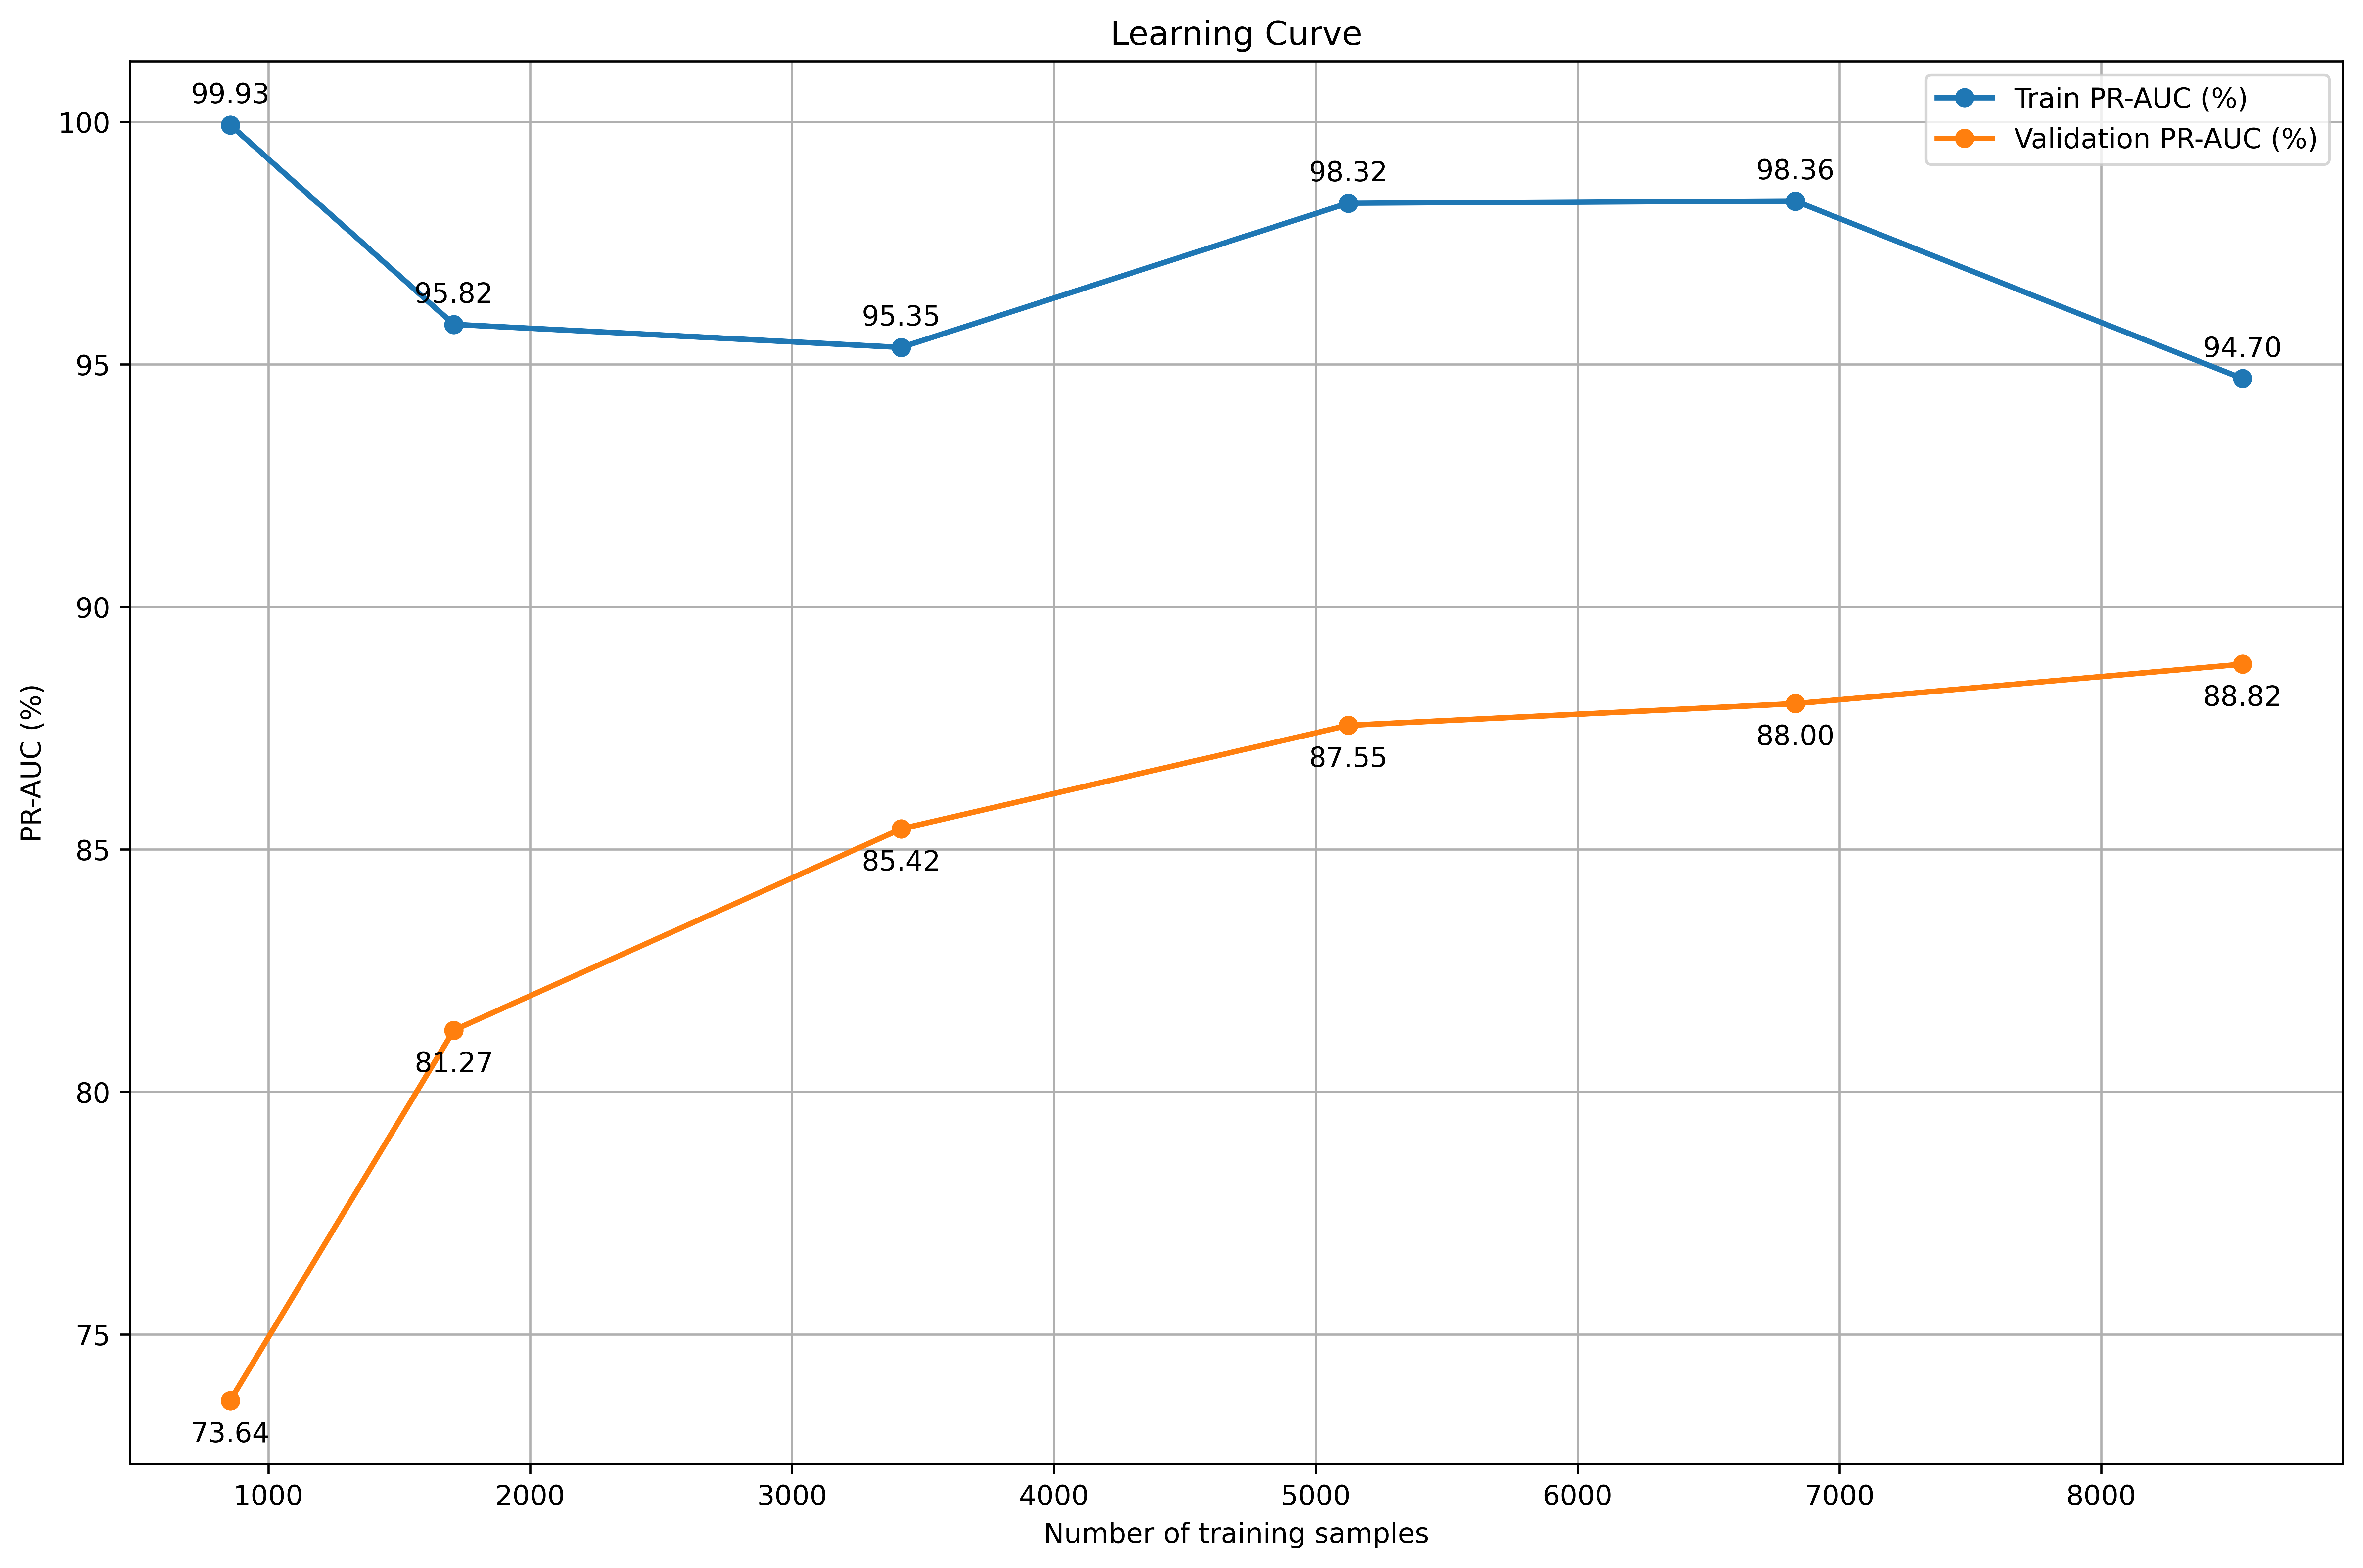

Saved figure to: C:\Users\Steven\Desktop\Final_project_202218020208_lighweight_pneumothorax_detection\ConvUnet\AutoDL\Baseline_ECA_LSMF_samplerUNetPP_GEMopt_AutoDL_Output\outputs_learning_curve\standard_learning_curve_pr_auc_with_labels.png


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ===== 1. Paths =====
PROJECT_ROOT = r"C:\Users\Steven\Desktop\Final_project_202218020208_lighweight_pneumothorax_detection\ConvUnet\AutoDL\Baseline_ECA_LSMF_samplerUNetPP_GEMopt_AutoDL_Output"
CSV_PATH = os.path.join(PROJECT_ROOT, "learning_curve_results.csv")
OUT_DIR = os.path.join(PROJECT_ROOT, "outputs_learning_curve")
os.makedirs(OUT_DIR, exist_ok=True)

# ===== 2. Read CSV =====
results_df = pd.read_csv(CSV_PATH)
results_df = results_df.sort_values("n_train").reset_index(drop=True)

# ===== 3. Plot standard learning curve =====
plt.figure(figsize=(12, 8), dpi = 600)

x = results_df["n_train"]
y_train = results_df["train_pr_auc"] * 100
y_val = results_df["val_pr_auc"] * 100

plt.plot(x, y_train, marker="o", linewidth=2, label="Train PR-AUC (%)")
plt.plot(x, y_val, marker="o", linewidth=2, label="Validation PR-AUC (%)")

for xi, yi in zip(x, y_train):
    plt.annotate(f"{yi:.2f}", (xi, yi), textcoords="offset points", xytext=(0, 8), ha="center")

for xi, yi in zip(x, y_val):
    plt.annotate(f"{yi:.2f}", (xi, yi), textcoords="offset points", xytext=(0, -15), ha="center")

plt.xlabel("Number of training samples")
plt.ylabel("PR-AUC (%)")
plt.title("Learning Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()

fig_path = os.path.join(OUT_DIR, "standard_learning_curve_pr_auc_with_labels.png")
plt.savefig(fig_path, dpi=220, bbox_inches="tight")
plt.show()

print("Saved figure to:", fig_path)